In [1]:
import os
os.chdir('..')
import sys
from gpu_management import set_gpus

os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform' 
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'
set_gpus(1, forcing=True)
print(f"XLA_PYTHON_CLIENT_ALLOCATOR set to: {os.environ.get('XLA_PYTHON_CLIENT_ALLOCATOR')}")
print(f"CUDA_VISIBLE_DEVICES set to: {os.environ.get('CUDA_VISIBLE_DEVICES')}")

XLA_PYTHON_CLIENT_ALLOCATOR set to: platform
CUDA_VISIBLE_DEVICES set to: 6


In [2]:
import pathlib
import pickle

new_set = False
filename = 'new' if new_set else 'same'
if new_set:
    path = pathlib.Path('experiments/results/NewSet2/results.pkl')
    with open(path, 'rb') as f:
        exp_args, results = pickle.load(f)
    path = pathlib.Path('experiments/results/NewSet2NoFT/results.pkl')
    with open(path, 'rb') as f:
        exp_args2, results2 = pickle.load(f)
    results += results2
else:
    path = pathlib.Path('experiments/results/SameSet2/results.pkl')
    with open(path, 'rb') as f:
        exp_args, results = pickle.load(f)

In [3]:
exp_args, len(results)

(Namespace(name='SameSet2', n_gpus=1, loss=['NLL', 'KL'], conf=['experiments/configs/sameset2.yml'], verbose=0, dataset={'train_set': ['BLB', 'FDN', 'TDM'], 'val_set': ['BLB', 'FDN', 'TDM'], 'test_set': ['BLB', 'FDN', 'TDM'], 'temporal_split': True, 'time_window': 14, 'data_head': -1, 'data_size': {'train_n_drafts': 119204, 'val_n_drafts': 113178, 'test_n_drafts': 64817}}, runs=[Namespace(model='Heuristic', model_params={}, encoder='gemma', tokenizer='bert', use_meta=True, graph_density=0.01, graph_type='knn', epochs=100, batch_size=256, optimizer='adamw', lr=0.0001, scheduler='warmup_cosine', scheduler_params={'init_mult': '1e-1', 'warmup_steps': 1, 'end_mult': '1e-1', 'n_restarts': 0, 'restart_factor': 1}, loss=['NLL', 'KL'], fine_tune=None, fine_tune_epochs=None, test_frequency=1, seed=42, dataset={'train_set': ['BLB', 'FDN', 'TDM'], 'val_set': ['BLB', 'FDN', 'TDM'], 'test_set': ['BLB', 'FDN', 'TDM'], 'temporal_split': True, 'time_window': 14, 'data_head': -1}, param_count=0), Names

In [4]:
from plot import make_labels

labels = make_labels([run['config'] for run in results], False, True)
labels

['Heuristic        ,use_meta=True ,lr=1e-04',
 'Heuristic        ,use_meta=True ,lr=1e-04',
 'Heuristic        ,use_meta=True ,lr=1e-04',
 'Constant         [dataset=train],use_meta=False,lr=1e-04',
 'Constant         [dataset=train],use_meta=False,lr=1e-04',
 'Constant         [dataset=train],use_meta=False,lr=1e-04',
 'Constant         [dataset=test ],use_meta=False,lr=1e-04',
 'Constant         [dataset=test ],use_meta=False,lr=1e-04',
 'Constant         [dataset=test ],use_meta=False,lr=1e-04',
 'DraftTransformer2,use_meta=True ,lr=1e-04',
 'DraftTransformer2,use_meta=True ,lr=1e-04',
 'DraftTransformer2,use_meta=True ,lr=1e-04',
 'DraftTransformer2,use_meta=False,lr=1e-04',
 'DraftTransformer2,use_meta=False,lr=1e-04',
 'DraftTransformer2,use_meta=False,lr=1e-04',
 'LinearRegression ,use_meta=False,lr=3e-05',
 'LinearRegression ,use_meta=False,lr=3e-05',
 'LinearRegression ,use_meta=False,lr=3e-05',
 'LinearRegression ,use_meta=True ,lr=3e-05',
 'LinearRegression ,use_meta=True ,l

In [5]:
data = {}
for label, run in zip(labels, results):
    if label not in data:
        data[label] = []
    data[label].append(run)

In [6]:
for k, v in data.items():
    print(k, len(v))

Heuristic        ,use_meta=True ,lr=1e-04 3
Constant         [dataset=train],use_meta=False,lr=1e-04 3
Constant         [dataset=test ],use_meta=False,lr=1e-04 3
DraftTransformer2,use_meta=True ,lr=1e-04 3
DraftTransformer2,use_meta=False,lr=1e-04 3
LinearRegression ,use_meta=False,lr=3e-05 3
LinearRegression ,use_meta=True ,lr=3e-05 3


In [7]:
data[labels[0]][0].keys()

dict_keys(['config', 'train_losses', 'val_losses', 'test_losses', 'lr', 'key', 'best_epoch', 'test_preds', 'test_trues', 'test_npicks'])

In [8]:
if new_set:
    model_name_label = {
        'Heuristic        ,use_meta=True ,lr=1e-04,fine_tune=None,fine_tune_epochs=None': 'Heuristic',
        'LinearRegression ,use_meta=False,lr=3e-05,fine_tune=None,fine_tune_epochs=None': 'LR',
        'LinearRegression ,use_meta=False,lr=3e-05,fine_tune=2   ,fine_tune_epochs=25  ': 'LR',
        'LinearRegression ,use_meta=False,lr=3e-05,fine_tune=5   ,fine_tune_epochs=25  ': 'LR',
        'LinearRegression ,use_meta=True ,lr=3e-05,fine_tune=None,fine_tune_epochs=None': 'LR+Meta',
        'LinearRegression ,use_meta=True ,lr=3e-05,fine_tune=2   ,fine_tune_epochs=25  ': 'LR+Meta',
        'LinearRegression ,use_meta=True ,lr=3e-05,fine_tune=5   ,fine_tune_epochs=25  ': 'LR+Meta',
        'DraftTransformer2,use_meta=False,lr=1e-04,fine_tune=None,fine_tune_epochs=None': 'DraftEncoder',
        'DraftTransformer2,use_meta=False,lr=1e-04,fine_tune=2   ,fine_tune_epochs=25  ': 'DraftEncoder [1 day]',
        'DraftTransformer2,use_meta=False,lr=1e-04,fine_tune=5   ,fine_tune_epochs=25  ': 'DraftEncoder [4 days]',
        'DraftTransformer2,use_meta=True ,lr=1e-04,fine_tune=None,fine_tune_epochs=None': 'DraftEncoder+Meta',
        'DraftTransformer2,use_meta=True ,lr=1e-04,fine_tune=2   ,fine_tune_epochs=25  ': 'DraftEncoder+Meta [1 day]',
        'DraftTransformer2,use_meta=True ,lr=1e-04,fine_tune=5   ,fine_tune_epochs=25  ': 'DraftEncoder+Meta [4 days]',
    }
else:
    model_name_label = {
        'Heuristic        ,use_meta=True ,lr=1e-04': 'Heuristic',
        'LinearRegression ,use_meta=False,lr=3e-05': 'LR',
        'LinearRegression ,use_meta=True ,lr=3e-05': 'LR+Meta',
        'DraftTransformer2,use_meta=False,lr=1e-04': 'DraftEncoder',
        'DraftTransformer2,use_meta=True ,lr=1e-04': 'DraftEncoder+Meta',
    }
model_name_color = {
    'Heuristic': 2,
    'LR': 3,
    'LR+Meta': 4,
    'DraftEncoder [1 day]': 0,
    'DraftEncoder+Meta [1 day]': 1,
    'DraftEncoder [4 days]': 0,
    'DraftEncoder+Meta [4 days]': 1,
    'DraftEncoder': 0.5,
    'DraftEncoder+Meta': 1.5
}

In [9]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta, spearmanr
import matplotlib.ticker as ticker

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 8 # 18

cmap = plt.get_cmap('tab20')

styles = ['-', '--', ':', '-.', (0, (6.4, 2.0, 1.0, 2.0, 1.0, 2.0))]

def calib_plot(y_probs, y_true, label, ax, color, bins=20):
    win_rate = y_true[:, 0] / y_true.sum(axis=1)

    x_edges = np.quantile(y_probs, np.linspace(0, 1, bins + 1))
    bin_indices = np.digitize(y_probs, x_edges) - 1
    bin_indices = np.clip(bin_indices, 0, bins-1)

    bin_pred = np.zeros(bins)
    bin_true = np.zeros(bins)
    bin_ci_low = np.zeros(bins)
    bin_ci_high = np.zeros(bins)
    bin_counts = np.zeros(bins, dtype=int)
    bin_mask = np.full(bins, False)

    for i in range(bins):
        mask = bin_indices == i
        if mask.sum() == 0:
            continue
        bin_mask[i] = True

        W = y_true[mask, 0].sum()
        L = y_true[mask, 1].sum()

        bin_pred[i] = y_probs[mask].mean()
        bin_true[i] = W / (W + L)
        # Not best distribution, but combining all game series in a bin reduces the error
        bin_ci_low[i] = beta.ppf(0.025, W + 1, L + 1)
        bin_ci_high[i] = beta.ppf(0.975, W + 1, L + 1)
        bin_counts[i] = mask.sum()

    bin_pred = bin_pred[bin_mask]
    bin_true = bin_true[bin_mask]
    bin_ci_low = bin_ci_low[bin_mask]
    bin_ci_high = bin_ci_high[bin_mask]
    bin_counts = bin_counts[bin_mask]

    ece = (bin_counts / bin_counts.sum() * np.abs(bin_pred - bin_true)).sum()

    min_x = bin_pred.min()
    max_x = bin_pred.max()

    min_y = min(bin_ci_low)
    max_y = max(bin_ci_high)

    nonempty = bin_counts > 0
    tmp_label = label.split(',fine_tune=')[0]
    tmp_label = f'{tmp_label} (ECE={ece:.3f})'
    ax.plot(bin_pred[nonempty], bin_true[nonempty], marker='+', markersize=2, label=tmp_label, color=cmap(int(2*color)), linestyle=styles[int(color)%len(styles)])
    ax.fill_between(
        bin_pred[nonempty],
        bin_ci_low[nonempty],
        bin_ci_high[nonempty],
        alpha=0.2,
        color=cmap(int(2*color))
    )
    return min_x, max_x, min_y, max_y

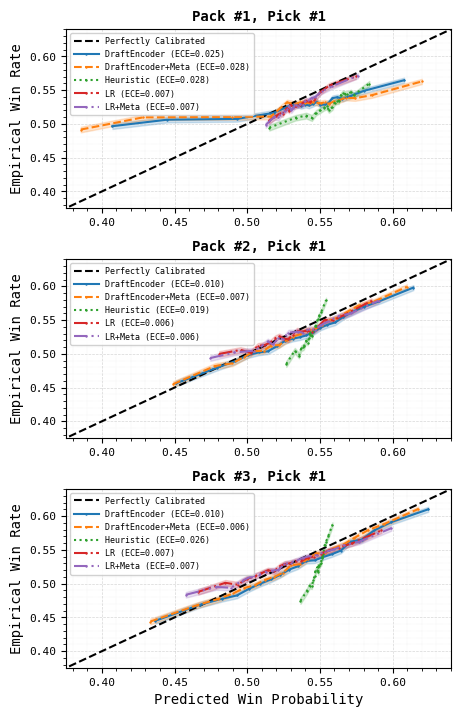

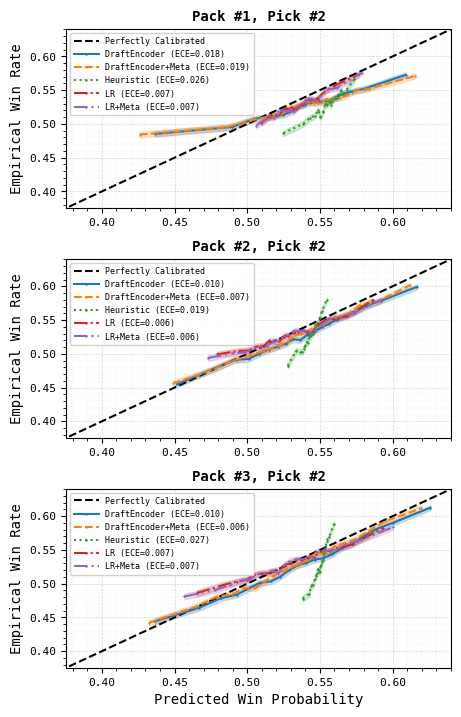

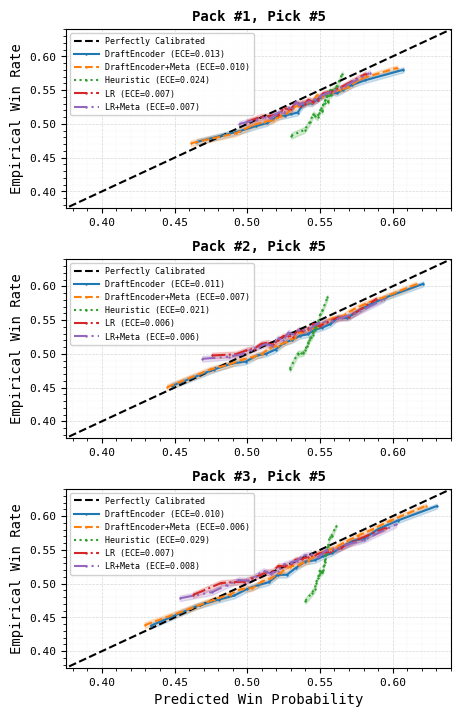

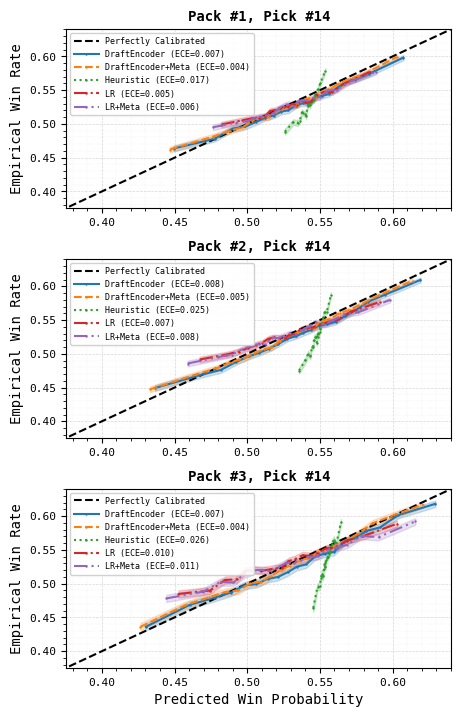

In [10]:
def calibration_plot(data, picks, pack_size=14, bins=20, label_dic=None, colormap=None):
    if label_dic is None:
        label_dic = {}
    if colormap is None:
        colormap = {}
    if picks is None:
        picks = [0, 3*pack_size-1]
    curves = {pick: [{} for _ in range(3)] for pick in picks}
    labels = []
    for label in data.keys():
        if label not in label_dic:
            continue
        text_label = label_dic.get(label, label)
        labels.append((colormap.get(text_label, np.inf), text_label))
        
        for run in data[label]:
            preds   = run['test_preds'][1].reshape((-1, 45))
            trues   = run['test_trues'][1].reshape((-1, 2))
            n_picks = run['test_npicks'][1].reshape((-1,))
        
            for i_pick in picks:
                for i_pack in range(3):
                    pick_num = i_pack * pack_size + i_pick
                    mask_pad = n_picks > pick_num
                    if mask_pad.sum() == 0:
                        continue
                    if text_label not in curves[i_pick][i_pack]:
                        curves[i_pick][i_pack][text_label] = {
                            'preds': [],
                            'trues': []
                        }
                    curves[i_pick][i_pack][text_label]['preds'].append(preds[:,pick_num][mask_pad])
                    curves[i_pick][i_pack][text_label]['trues'].append(trues[mask_pad])

    labels = sorted(labels)
    models = []
    last_color = -1
    for color, label in labels:
        if color == np.inf:
            color = last_color + 1
        models.append((label, int(color)))
        last_color = color
    figs = {}
    axss = {}
    mini = 1
    maxi = 0
    for i_pick in picks:
        fig, axs = plt.subplots(3, 1, figsize=(335/72, 335/72*3.1/6*3))
        figs[i_pick] = fig
        axss[i_pick] = axs
        for i_pack in range(3):
            ax = axs[i_pack]
            ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')

            for label, color in models:
                x_min, x_max, y_min, y_max = calib_plot(
                    np.concatenate(curves[i_pick][i_pack][label]['preds']),
                    np.concatenate(curves[i_pick][i_pack][label]['trues']),
                    label, ax, color, bins=bins
                )

                mini = min(mini, x_min, y_min)
                maxi = max(maxi, x_max, y_max)
            
            if i_pack == 2:
                ax.set_xlabel('Predicted Win Probability', fontsize=10)
            ax.set_ylabel('Empirical Win Rate', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
            ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.3)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax.legend(fontsize=6, framealpha=0.9, handlelength=3)
            title = f'Pack #{i_pack+1}, Pick #{i_pick+1}'
            ax.set_title(title, fontsize=10, fontweight='bold')

            
    padding = 0.01
    mini -= padding
    maxi += padding
    for i_pick in picks:
        fig = figs[i_pick]
        axs = axss[i_pick]
        for i_pack in range(3):
            ax = axs[i_pack]
            ax.set_xlim(mini, maxi)
            ax.set_ylim(mini, maxi)
        fig.tight_layout()
        fig.savefig(f'figures/picks_calib_plot_{filename}_pick{i_pick+1:02}.pdf')

if not new_set:
    calibration_plot(data, [0, 1, 4, 13], 14, label_dic=model_name_label, colormap=model_name_color)

In [11]:
import re

def picks_ft_calibration_plot(data, fine_tune, pack_size=14, picks=None, bins=20, label_dic=None, colormap=None):
    if label_dic is None:
        label_dic = {}
    if colormap is None:
        colormap = {}
    if picks is None:
        picks = [0, 3*pack_size-1]
    curves = {pick_num: {ft: {} for ft in fine_tune} for pick_num in picks}
    labels = set()
    for label in data.keys():
        if label not in label_dic or 'fine_tune=' not in label:
            continue
        ft = re.search(r"fine_tune=([0-9]+|None)", label).group(1)
        if ft != 'None':
            ft = int(ft)
        if label[:9] == 'Heuristic' and ft != 'None':
            continue
        text_label = label_dic.get(label, label).split()[0]
        labels.add((colormap.get(text_label, np.inf), text_label))
        
        for run in data[label]:
            preds   = run['test_preds'][1].reshape((-1, 45))
            trues   = run['test_trues'][1].reshape((-1, 2))
            n_picks = run['test_npicks'][1].reshape((-1,))
        
            for pick_num in picks:
                mask_pad = n_picks > pick_num
                if mask_pad.sum() == 0:
                    continue
                if text_label not in curves[pick_num][ft]:
                    curves[pick_num][ft][text_label] = {
                        'preds': [],
                        'trues': []
                    }
                curves[pick_num][ft][text_label]['preds'].append(preds[:,pick_num][mask_pad])
                curves[pick_num][ft][text_label]['trues'].append(trues[mask_pad])

    labels = sorted(labels)
    models = []
    last_color = -1
    for color, label in labels:
        if color == np.inf:
            color = last_color + 1
        models.append((label, int(color)))
        last_color = color
    figs = {}
    axss = {}
    mini = 1
    maxi = 0
    for pick_num in picks:
        fig, axs = plt.subplots(len(fine_tune), 1, figsize=(335/72, 335/72*3.1/6*len(fine_tune)))
        figs[pick_num] = fig
        axss[pick_num] = axs
        for i_ft, ft in enumerate(fine_tune):
            ax = axs[i_ft]
            ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')

            for label, color in models:
                if label not in curves[pick_num][ft]:
                    continue
                x_min, x_max, y_min, y_max = calib_plot(
                    np.concatenate(curves[pick_num][ft][label]['preds']),
                    np.concatenate(curves[pick_num][ft][label]['trues']),
                    label, ax, color, bins=bins
                )

                mini = min(mini, x_min, y_min)
                maxi = max(maxi, x_max, y_max)
            
            if i_ft == len(fine_tune)-1:
                ax.set_xlabel('Predicted Win Probability', fontsize=10)
            ax.set_ylabel('Empirical Win Rate', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
            ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.3)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax.legend(fontsize=6, framealpha=0.9, handlelength=3)
            if ft == 'None':
                title = 'No fine-tuning'
            else:
                title = f'{ft-1} day{'s' if ft > 2 else ''} of fine-tuning'
            title += f', Pack #{pick_num//pack_size+1}, Pick #{(pick_num%pack_size)+1}'
            ax.set_title(title, fontsize=10, fontweight='bold')

            
    padding = 0.01
    mini -= padding
    maxi += padding
    for pick_num in picks:
        fig = figs[pick_num]
        axs = axss[pick_num]
        for i_ft, ft in enumerate(fine_tune):
            ax = axs[i_ft]
            ax.set_xlim(mini, maxi)
            ax.set_ylim(mini, maxi)
        fig.tight_layout()
        fig.savefig(f'figures/picks_calib_plot_{filename}_pick{pick_num+1:02}.pdf')

if new_set:
    picks_ft_calibration_plot(data, ['None', 2, 5], picks=[0, 3, 14, 41], label_dic=model_name_label, colormap=model_name_color)

Heuristic        ,use_meta=True ,lr=1e-04 Heuristic
DraftTransformer2,use_meta=True ,lr=1e-04 DraftEncoder+Meta
DraftTransformer2,use_meta=False,lr=1e-04 DraftEncoder
LinearRegression ,use_meta=False,lr=3e-05 LR
LinearRegression ,use_meta=True ,lr=3e-05 LR+Meta


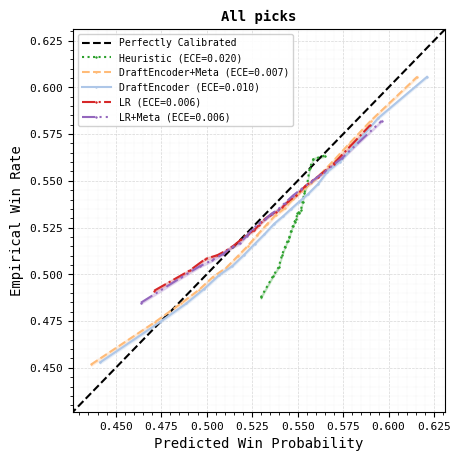

In [12]:
def full_calibration_plot(data, bins=20, first_seed=False, label_dic=None, colormap=None):
    fig, ax = plt.subplots(1, 1, figsize=(335/72, 335/72))
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    min_x, max_x = 1, 0
    min_y, max_y = 1, 0
    for i_color, label in enumerate(data.keys()):
        if label_dic is not None and label not in label_dic:
            continue
        if f'fine_tune=5' in label or (f'fine_tune=2' in label and 'LinearRegression' in label):
            continue
        all_preds = []
        all_trues = []
        for i_pick in range(45):
            for run in data[label]:
                preds = run['test_preds']
                trues = run['test_trues']
                y_probs = preds[1].reshape((-1, 45))[:,i_pick]
                y_true = trues[1].reshape((-1, 2))
                n_picks = run['test_npicks'][1].reshape((-1,))
                mask_pad = i_pick < n_picks
                if mask_pad.sum() == 0:
                    continue
                y_probs = y_probs[mask_pad]
                y_true = y_true[mask_pad]

                all_preds.append(y_probs)
                all_trues.append(y_true)
        
                if first_seed:
                    break

        if label_dic is None:
            text_label = label
        else:
            text_label = label_dic.get(label, label)
            print(label, text_label)
        if colormap is None:
            color = i_color
        else:
            color = colormap.get(text_label, i_color)
        x_min, x_max, y_min, y_max = calib_plot(np.concatenate(all_preds), np.concatenate(all_trues), text_label, ax, color, bins=bins)

        min_x = min(min_x, x_min)
        max_x = max(max_x, x_max)

        min_y = min(min_y, y_min)
        max_y = max(max_y, y_max)

    ax.set_xlabel('Predicted Win Probability', fontsize=10)
    ax.set_ylabel('Empirical Win Rate', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)
    padding = 0.01
    maxi = max(max_x, max_y)
    mini = min(min_x, min_y)
    ax.set_xlim(mini - padding, maxi + padding)
    ax.set_ylim(mini - padding, maxi + padding)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.3)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(fontsize=7, framealpha=0.9, handlelength=3)
    ax.set_title(f'All picks', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/full_calib_plot_{filename}.pdf')

full_calibration_plot(data, first_seed=False, label_dic=model_name_label, colormap=model_name_color)

In [13]:
spearmans = {}
for color, label in enumerate(data.keys()):
    if label[:8] == 'Constant':
        continue
    spearmans[label] = {}
    for i_pick in range(45):
        spearmans[label][i_pick] = []
        for run in data[label]:
            preds = run['test_preds']
            trues = run['test_trues']
            y_probs = preds[1].reshape((-1, 45))[:,i_pick]
            y_true = trues[1].reshape((-1, 2))
            n_picks = run['test_npicks'][1].reshape((-1,))
            mask_pad = i_pick < n_picks
            if mask_pad.sum() == 0:
                continue
            y_probs = y_probs[mask_pad]
            y_true = y_true[mask_pad]

            win_rate = y_true[:, 0] / y_true.sum(axis=1)
            spearmans[label][i_pick].append((spearmanr(y_probs, win_rate), mask_pad.sum()))

/home/trigaux/MTGateau/.pixi/envs/default/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/trigaux/MTGateau/.pixi/envs/default/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


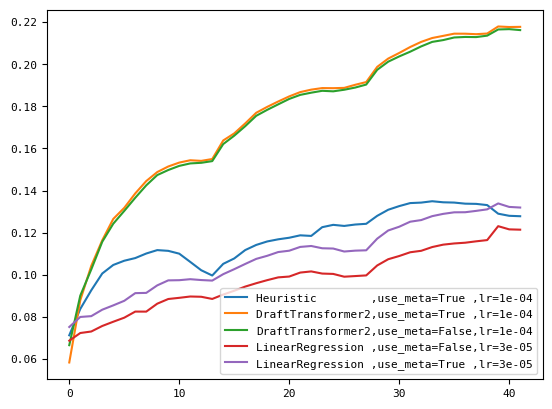

In [14]:
for label, picks in spearmans.items():
    X = list(picks.keys())
    plt.plot(X, [np.mean([p.statistic for p, w in picks[x]]) for x in X], label=label)
plt.legend()
# plt.savefig('figures/spearman_corr.png')

In [15]:
def spearman_plot(spearmans, smooth_sigma=1.0, figsize=(3.5, 2), fine_tune=None, label_dic=None, colormap=None, y_lim=None, legend_args={}):
    fig, ax = plt.subplots(figsize=figsize)
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 10,
        'axes.linewidth': 0.5,
    })

    colors = plt.cm.tab10.colors
    res = {}

    for i, (label, picks) in enumerate(spearmans.items()):
        if new_set:
            if f'fine_tune={fine_tune}' not in label and label[:9] != 'Heuristic':
                continue
            if label[:9] == 'Heuristic' and ('fine_tune=2' in label or 'fine_tune=5' in label):
                continue
        X = np.array(list(picks.keys()))
        X = X[:42]
        coeffs = {x: [p for p, w in picks[x]] for x in X}
        weights = {x: [w for p, w in picks[x]] for x in X}
        means = np.array([np.mean([p.statistic for p in coeffs[x]]) for x in X])
        w = np.array([np.sum(weights[x]) for x in X])
        stds = np.array([np.std(coeffs[x]) / 20 for x in X])

        X = X+1
        coeffs_flat  = np.array([v.statistic for vs in coeffs.values()  for v in vs])
        weights_flat = np.array([v for vs in weights.values() for v in vs])
        
        total_mean = np.average(coeffs_flat, weights=weights_flat)
        total_std  = np.sqrt(np.average((coeffs_flat - total_mean)**2, weights=weights_flat))

        for x in (X-1)[::-1]:
            if len(coeffs[x]) == 0:
                continue
            coeffs_last  = np.array([v.statistic for v in coeffs[x]])
            weights_last = np.array([v for v in weights[x]])
            break
            
        last_mean = np.average(coeffs_last, weights=weights_last)
        last_std  = np.sqrt(np.average((coeffs_last - last_mean)**2, weights=weights_last))
        res[label] = (
            (total_mean, total_std),
            (last_mean, last_std),
        )
        
        tmp_label = label
        if label_dic is not None:
            tmp_label = label_dic[label]

        i_color = i
        if colormap is not None:
            i_color = colormap[tmp_label]
        color = colors[int(i_color) % len(colors)]
        style = styles[int(i_color) % len(styles)]

        ax.plot(X, means, linestyle=style, color=color, linewidth=1, label=tmp_label)
        ax.fill_between(X, means - stds, means + stds, alpha=0.15, color=color)

    max_total = list(res.keys())[0]
    max_last = list(res.keys())[0]
    second_total = list(res.keys())[1]
    second_last = list(res.keys())[1]
    if res[second_total][0][0] > res[max_total][0][0]:
        max_total, second_total = second_total, max_total
    if res[second_last][0][0] > res[max_last][0][0]:
        max_last, second_last = second_last, max_last
    for label in res:
        if max_total == label or second_total == label:
            continue
        if res[label][0][0] > res[max_total][0][0]:
            second_total = max_total
            max_total = label
        elif res[label][0][0] > res[second_total][0][0]:
            second_total = label
        if res[label][1][0] > res[max_last][1][0]:
            second_last = max_last
            max_last = label
        elif res[label][1][0] > res[second_last][1][0]:
            second_last = label
    text = {}
    def format(s, label, label_max, label_second):
        if label == label_max:
            return f'$\\bm{{{s}}}$'
        if label == label_second:
            return f'$\\underline{{{s}}}$'
        return f'${s}$'
    len_max, len_last = 0, 0
    for label in res:
        txt_total = f'{res[label][0][0]:.4f} \\pm {res[label][0][1]:.4f}'
        txt_last =  f'{res[label][1][0]:.4f} \\pm {res[label][1][1]:.4f}'
        text[label] = (
            format(txt_total, label, max_total, second_total),
            format(txt_last, label, max_last, second_last),
        )
        len_max = max(len_max, len(text[label][0]))
        len_last = max(len_last, len(text[label][1]))
    for label in res:
        print(label)
        print(f'{text[label][0]:<{len_max}} & {text[label][1]:<{len_last}} \\\\')

    ax.set_xlabel('Pick number', fontsize=10)
    ax.set_ylabel('Spearman ρ', fontsize=10)
    ax.tick_params(axis='both', labelsize=8, width=0.5)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, which='major', linestyle='--', linewidth=0.3, alpha=0.5)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.2, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    if new_set and fine_tune != None:
        my_order = [4, 0, 1, 2, 3]
    else:
        my_order = range(5)
    assert(len(my_order) == len(labels))
    ax.legend(
        [handles[i] for i in my_order], [labels[i] for i in my_order],
        framealpha=0.9, loc='upper left', fontsize=8,
        handlelength=2, handletextpad=0.4, labelspacing=0.3, **legend_args
    )
    ax.set_xlim(X.min(), X.max())
    if y_lim is None:
        ax.set_ylim(0.04, 0.2377)
    else:
        ax.set_ylim(*y_lim)
    #ax.set_ylim(0.07)
    fig.tight_layout(pad=0.5)
    name = filename
    if new_set:
        x = fine_tune if fine_tune is not None else 1
        name += f'_ft{x-1}'
    if len(legend_args) > 0:
        name += '_wide'
    plt.savefig(f'figures/spearman_corr_{name}.pdf', bbox_inches='tight')
    plt.show()

Heuristic        ,use_meta=True ,lr=1e-04
$0.1166 \pm 0.0147$             & $0.1278 \pm 0.0002$             \\
DraftTransformer2,use_meta=True ,lr=1e-04
$\bm{0.1735 \pm 0.0377}$        & $\bm{0.2177 \pm 0.0023}$        \\
DraftTransformer2,use_meta=False,lr=1e-04
$\underline{0.1723 \pm 0.0368}$ & $\underline{0.2162 \pm 0.0005}$ \\
LinearRegression ,use_meta=False,lr=3e-05
$0.0972 \pm 0.0139$             & $0.1214 \pm 0.0010$             \\
LinearRegression ,use_meta=True ,lr=3e-05
$0.1083 \pm 0.0162$             & $0.1319 \pm 0.0005$             \\


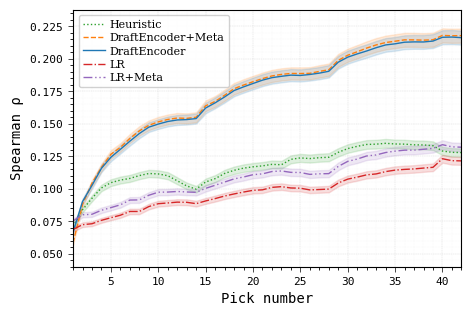

In [16]:
spearman_plot(spearmans, label_dic=model_name_label, figsize=(335/72, 335/72*4/6), colormap=model_name_color)

Heuristic        ,use_meta=True ,lr=1e-04
$0.1166 \pm 0.0147$             & $0.1278 \pm 0.0002$             \\
DraftTransformer2,use_meta=True ,lr=1e-04
$\bm{0.1735 \pm 0.0377}$        & $\bm{0.2177 \pm 0.0023}$        \\
DraftTransformer2,use_meta=False,lr=1e-04
$\underline{0.1723 \pm 0.0368}$ & $\underline{0.2162 \pm 0.0005}$ \\
LinearRegression ,use_meta=False,lr=3e-05
$0.0972 \pm 0.0139$             & $0.1214 \pm 0.0010$             \\
LinearRegression ,use_meta=True ,lr=3e-05
$0.1083 \pm 0.0162$             & $0.1319 \pm 0.0005$             \\


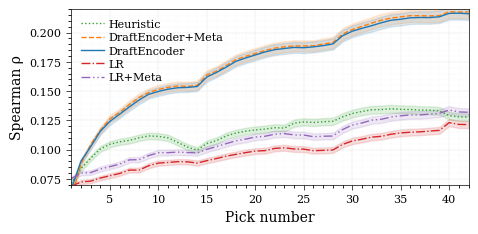

In [17]:
spearman_plot(spearmans, label_dic=model_name_label, figsize=(335/72, 335/72*3/6), colormap=model_name_color, y_lim=(0.07,0.22), legend_args={'frameon': False})

In [18]:
if new_set:
    spearman_plot(spearmans, label_dic=model_name_label, figsize=(335/72, 335/72*4/6), colormap=model_name_color, fine_tune=2)
    spearman_plot(spearmans, label_dic=model_name_label, figsize=(335/72, 335/72*4/6), colormap=model_name_color, fine_tune=5)

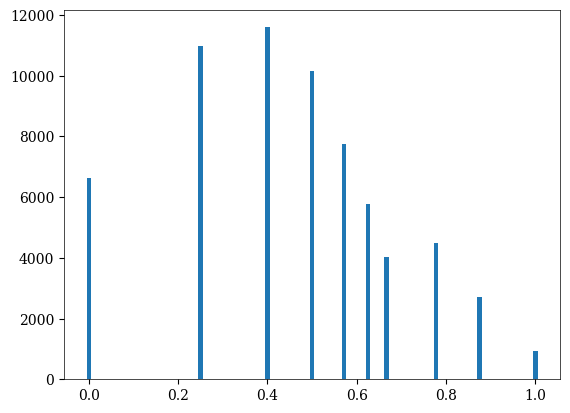

In [19]:
def hists(runs):
    for run in runs:
        # preds = run['test_preds']
        trues = run['test_trues']
        #print(preds[BEST_EPOCH][1].shape)
        #print(trues[BEST_EPOCH][1].shape)
        # y_probs = preds[BEST_EPOCH][1].reshape((-1, 45))[:,-1]
        y_true = trues[1].reshape((-1, 2))
        y_true = y_true[:,0] / y_true.sum(axis=1)

        bins = {}
        for p in y_true:
            if p not in bins:
                bins[p] = 0
            bins[p] += 1

        plt.bar(bins.keys(), bins.values(), width=0.01)
        return

hists(data[labels[0]])

(None, (array([1, 7, 0]), array([3, 0, 3])))

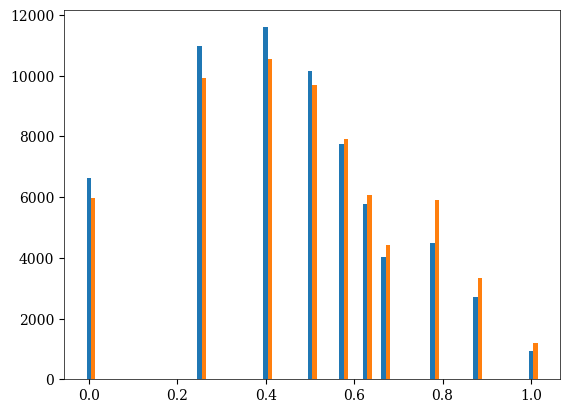

In [20]:
from scipy.stats import truncnorm

def sample_series_fast(p, rng=None):
    """
    p: (n,) array of probabilities
    returns W, L: (n,)
    """
    p = np.asarray(p)
    if rng is None:
        rng = np.random.default_rng()
    elif isinstance(rng, int):
        rng = np.random.default_rng(rng)
    games = rng.random((len(p), 9)) < p[:, None]
    wins   = np.cumsum(games,  axis=1)
    losses = np.cumsum(~games, axis=1)
    done = (wins == 7) | (losses == 3)
    stop = np.argmax(done, axis=1)
    W = wins  [np.arange(len(p)), stop]
    L = losses[np.arange(len(p)), stop]
    return W, L

def abs_truncnorm(loc=0., scale=1., size=1, a=0, b=1, seed=None):
    x = (a - loc) / scale
    y = (b - loc) / scale
    return truncnorm.rvs(x, y, loc=loc, scale=scale, size=size, random_state=seed)

def sim(runs, mean_p=0.55, std_p=0.05):
    for run in runs:
        # preds = run['test_preds']
        trues = run['test_trues']
        #print(preds[BEST_EPOCH][1].shape)
        #print(trues[BEST_EPOCH][1].shape)
        # y_probs = preds[BEST_EPOCH][1].reshape((-1, 45))[:,-1]
        y_true = trues[1].reshape((-1, 2))

        n = y_true.shape[0]
        p = abs_truncnorm(loc=mean_p, scale=std_p, size=n)
        w, l = sample_series_fast(p)
        
        p_true = y_true[:,0] / y_true.sum(axis=1)
        
        bins = {}
        for p in p_true:
            if p not in bins:
                bins[p] = 0
            bins[p] += 1

        plt.bar(bins.keys(), bins.values(), width=0.01)
        y_true = np.zeros_like(y_true)
        y_true[:, 0] = w
        y_true[:, 1] = l
        
        p_true = y_true[:,0] / y_true.sum(axis=1)
        
        bins = {}
        for p in p_true:
            if p not in bins:
                bins[p] = 0
            bins[p] += 1

        plt.bar(np.array(list(bins.keys()))+0.01, bins.values(), width=0.01)
        return

sim(data[labels[0]]), sample_series_fast([0.55, 1, 0])

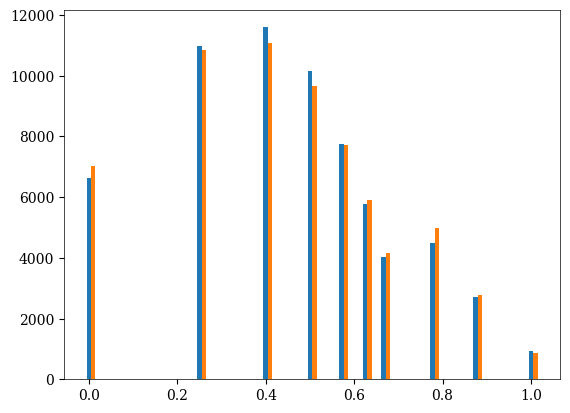

In [31]:
sim(data[labels[0]], mean_p=0.53)

In [21]:
from scipy.special import comb as sp_comb

def choose(k, n):
    return sp_comb(n, k, exact=False).astype(int)
    
def P(w, l, p):
    if w == 7:
        return choose(6, 6+l) * p ** 7 * (1 - p) ** l
    if l == 3:
        return choose(2, 2+w) * p ** w * (1 - p) ** 3
    assert False
for w in range(7):
    print(w, 3, w / (3 + w), P(w, 3, 0.4))
for l in range(2, -1, -1):
    print(7, l, 7 / (7 + l), P(7, l, 0.4))

0 3 0.0 0.21599999999999997
1 3 0.25 0.2592
2 3 0.4 0.20736000000000002
3 3 0.5 0.13824
4 3 0.5714285714285714 0.082944
5 3 0.625 0.046448640000000006
6 3 0.6666666666666666 0.024772608000000005
7 2 0.7777777777777778 0.016515072000000006
7 1 0.875 0.006881280000000003
7 0 1.0 0.0016384000000000006


0.5297985421628365 0.05342975533277843


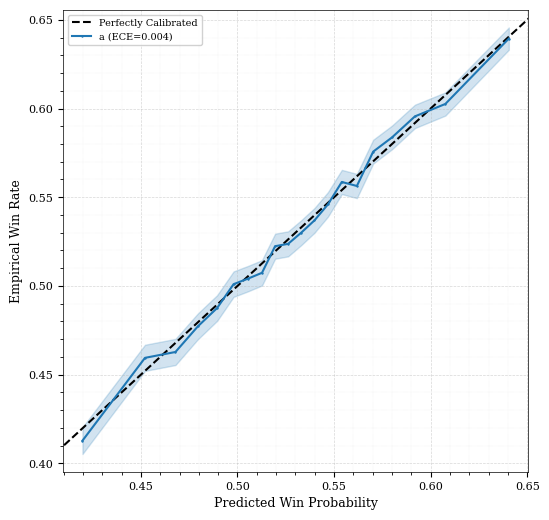

In [22]:
from numpy import arctanh, tanh, sqrt
from scipy.stats import norm

def combine_spearman(stats, ns):
    """
    stats: array of Spearman r values
    ns:    array of sample sizes for each
    """
    # Fisher z-transform: z = arctanh(r)
    zs = arctanh(stats)
    
    # Weighted average by (n - 3), the variance-stabilizing weight
    weights = ns - 3
    z_combined = np.average(zs, weights=weights)
    
    # Standard error of the combined z
    se = sqrt(1.0 / weights.sum())
    
    # Two-tailed p-value
    p = 2 * norm.sf(abs(z_combined / se))
    
    # Transform back to r
    r_combined = tanh(z_combined)
    
    return r_combined, p

def single_plot(p, y_true, color=0, figax=None, minmax=None):
    if figax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
        ax.set_xlabel('Predicted Win Probability', fontsize=9)
        ax.set_ylabel('Empirical Win Rate', fontsize=9)
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.3)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        # ax.set_title(f'Pick #{i_pick + 1}', fontsize=10, fontweight='bold')
    else:
        fig, ax = figax
    if minmax is None:
        minx, maxx, miny, maxy = np.inf, -np.inf, np.inf, -np.inf
    else:
        minx, maxx, miny, maxy = minmax
    min_x, max_x, min_y, max_y = calib_plot(p, y_true, 'a', ax, color)
    minx = min(minx, min_x)
    maxx = max(maxx, max_x)
    miny = min(miny, min_y)
    maxy = max(maxy, max_y)
    padding = 0.01
    ax.set_xlim(minx - padding, maxx + padding)
    ax.set_ylim(miny - padding, maxy + padding)
    ax.legend(fontsize=7, framealpha=0.9)

def oracle_eval(runs, mean_p=None, std_p=None):
    for run in runs:
        trues = run['test_trues']
        y_true = trues[1].reshape((-1, 2))
        p_true = y_true[:,0] / y_true.sum(axis=1)
        if mean_p is None:
            mean_p = np.average(p_true, weights=y_true.sum(axis=1))
        if std_p is None:
            std_p = np.sqrt(np.cov(p_true, aweights=y_true.sum(axis=1))) / 4
        print(mean_p, std_p)
        # sim(runs, mean_p, std_p)

        n = y_true.shape[0]
        p = abs_truncnorm(loc=mean_p, scale=std_p, size=n)
        w, l = sample_series_fast(p)
        y_true = np.zeros_like(y_true)
        y_true[:, 0] = w
        y_true[:, 1] = l

        single_plot(p, y_true)
        return mean_p, std_p, n

mean_p, std_p, n_samples = oracle_eval(data[labels[0]])

In [23]:
seed=42
synth_p = abs_truncnorm(loc=0.53, scale=0.05, size=20000, seed=seed)
synth_w, synth_l = sample_series_fast(synth_p, rng=seed)
synth_y_true = np.stack([synth_w, synth_l]).T
synth_y_true.shape

(20000, 2)

In [24]:
def NLL_wr(
    y_pred, #: Float[Array, "bs n_picks"],
    y_true, #: Int[Array, "bs 2"],
    eps=1e-4
): # -> Float[Array, "bs n_picks"]:
    W = y_true[:,0,None]
    L = y_true[:,1,None]
    p = np.clip(y_pred, eps, 1-eps)
    log_p_win_cap = (
        np.log(choose(6, 6 + L)) +
        7 * np.log(p) +
        L * np.log1p(-p)
    )
    log_p_loss_cap = (
        np.log(choose(2, W + 2)) +
        W * np.log(p) +
        3 * np.log1p(-p)
    )
    biased_log_p = np.where(
        (y_true[:,0] == 7).reshape((-1, 1)),
        log_p_win_cap,
        log_p_loss_cap
    )
    return -biased_log_p

def KL_wr(y_pred, y_true, eps=1e-4):
    return NLL_wr(y_pred, y_true, eps) - NLL_wr((y_true[:,0] / y_true.sum(axis=1))[:,None], y_true, eps)

NLL_wr(synth_p.reshape((-1, 1)), synth_y_true).mean(), KL_wr(synth_p.reshape((-1, 1)), synth_y_true).mean()

(np.float64(2.1279951140010214), np.float64(0.6356588098355823))

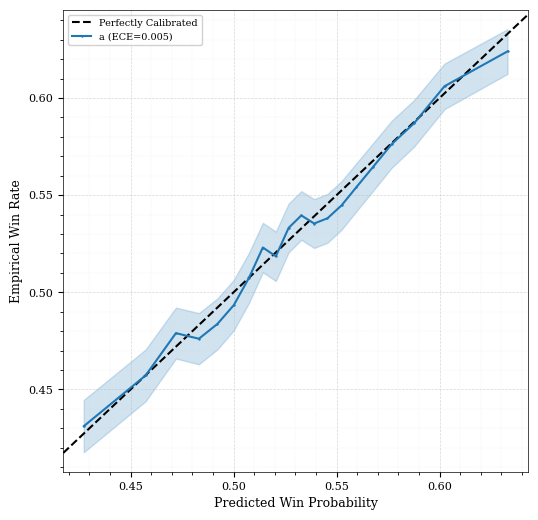

In [25]:
single_plot(synth_p, synth_y_true)

In [32]:
win_rate = synth_y_true[:, 0] / synth_y_true.sum(axis=1)
spearmanr(synth_p, win_rate)

SignificanceResult(statistic=np.float64(0.22076166077371626), pvalue=np.float64(2.7588507858448327e-219))

In [33]:
mean_p, std_p

(np.float64(0.5297985421628365), np.float64(0.05342975533277843))

0.5297985421628365 0.05342975533277843 (np.float64(0.2382053111001393), np.float64(0.0)) (np.float64(0.2396187079845998), np.float64(0.0))


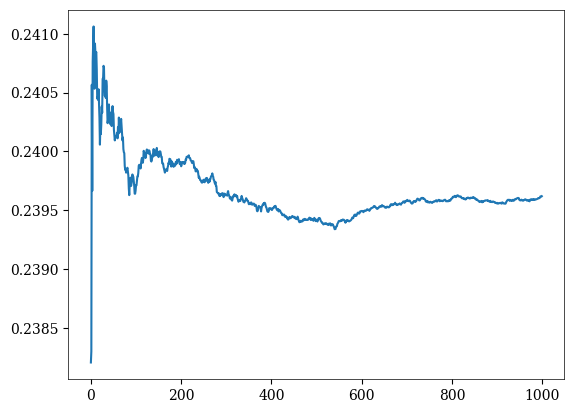

In [34]:
res = []
n_spearman = 1000
for _ in range(n_spearman):
    p = abs_truncnorm(loc=mean_p, scale=std_p, size=n_samples)
    w, l = sample_series_fast(p)
    y_true = np.zeros((n_samples, 2), dtype=np.int32)
    y_true[:, 0] = w
    y_true[:, 1] = l

    win_rate = y_true[:, 0] / y_true.sum(axis=1)
    res.append(spearmanr(p, win_rate))
    # print(res[-1])
comb = []
stats = np.array([r.statistic for r in res])
for i in range(n_spearman):
    comb.append(combine_spearman(
        stats[:i+1],
        np.full(i+1, n_samples)
    ))
print(mean_p, std_p, comb[0], comb[-1])
plt.plot([a for a, _ in comb])

0.5297985421628365 0.05342975533277843 (np.float64(0.23761298408524437), np.float64(0.0)) (np.float64(0.23772859794435408), np.float64(0.0))


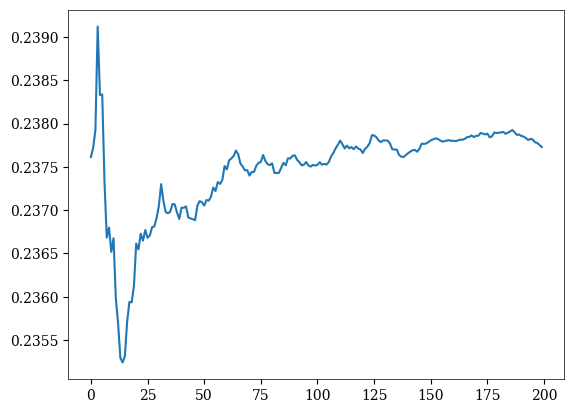

In [28]:
res = []
n_spearman = 200
for _ in range(n_spearman):
    p = abs_truncnorm(loc=0.53, scale=0.053, size=n_samples)
    w, l = sample_series_fast(p)
    y_true = np.zeros((n_samples, 2), dtype=np.int32)
    y_true[:, 0] = w
    y_true[:, 1] = l

    win_rate = y_true[:, 0] / y_true.sum(axis=1)
    res.append(spearmanr(p, win_rate))
    # print(res[-1])
comb = []
stats = np.array([r.statistic for r in res])
for i in range(n_spearman):
    comb.append(combine_spearman(
        stats[:i+1],
        np.full(i+1, n_samples)
    ))
print(mean_p, std_p, comb[0], comb[-1])
plt.plot([a for a, _ in comb])

In [29]:
p = abs_truncnorm(loc=0.53, scale=0.05, size=10000)
w, l = sample_series_fast(p)
y_true = np.zeros((10000, 2), dtype=np.int32)
y_true[:, 0] = w
y_true[:, 1] = l
NLL_wr(p.reshape((-1, 1)), y_true).mean(), KL_wr(p.reshape((-1, 1)), y_true).mean()

(np.float64(2.1330408024232788), np.float64(0.6480684719034357))